In [1]:
#===================================================
#
# LLM Evaluation and Regression Testing Framework
#
# MLOps Project
#
# Pablo Rodriguez
#
#
#

In [2]:
import json
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    ConfusionMatrixDisplay
)

MIN_ACCURACY = 0.85
MAX_ACCURACY_REGRESSION = 0.02
MAX_F1_REGRESSION = 0.02
MAX_CLASS_REGRESSION = 0.10
MAX_FAILURE_RATE = 0.05
MAX_NEW_REGRESSIONS = 1

ARTIFACT_DIR = Path("llm_eval_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

In [3]:
golden_data = pd.DataFrame([
    # SOFTWARE
    ("Develops backend APIs and software systems", "SOFTWARE"),
    ("Writes Python applications and maintains code", "SOFTWARE"),
    ("Builds web applications for customers", "SOFTWARE"),
    ("Designs and tests enterprise software", "SOFTWARE"),
    ("Maintains application code and fixes bugs", "SOFTWARE"),
    ("Creates APIs connecting internal business systems", "SOFTWARE"),

    # FINANCE
    ("Analyzes financial reports and budgets", "FINANCE"),
    ("Prepares company financial statements", "FINANCE"),
    ("Reviews investment performance and risk", "FINANCE"),
    ("Manages accounting records and expenses", "FINANCE"),
    ("Performs financial forecasting and analysis", "FINANCE"),
    ("Reviews company budgets and prepares forecasts", "FINANCE"),

    # HEALTHCARE
    ("Provides medical care to hospital patients", "HEALTHCARE"),
    ("Assists physicians with patient treatment", "HEALTHCARE"),
    ("Monitors patient health and medications", "HEALTHCARE"),
    ("Provides nursing care in a clinic", "HEALTHCARE"),
    ("Supports patient treatment and medical procedures", "HEALTHCARE"),
    ("Works in a clinic providing care and treatment", "HEALTHCARE"),

    # EDUCATION
    ("Teaches mathematics to high school students", "EDUCATION"),
    ("Develops classroom lessons and assessments", "EDUCATION"),
    ("Provides instruction to elementary students", "EDUCATION"),
    ("Teaches science courses at a school", "EDUCATION"),
    ("Evaluates student assignments and learning", "EDUCATION"),
    ("Creates instructional material for classroom use", "EDUCATION"),

    # TRADES
    ("Installs electrical systems in buildings", "TRADES"),
    ("Repairs plumbing and water systems", "TRADES"),
    ("Performs construction and building maintenance", "TRADES"),
    ("Repairs heating and cooling equipment", "TRADES"),
    ("Installs and repairs residential wiring", "TRADES"),
    ("Maintains building electrical and mechanical equipment", "TRADES"),

], columns=[
    "text",
    "expected_label"
])

golden_data.head()

,text,expected_label
0,Develops backend APIs and software systems,SOFTWARE
1,Writes Python applications and maintains code,SOFTWARE
2,Builds web applications for customers,SOFTWARE
3,Designs and tests enterprise software,SOFTWARE
4,Maintains application code and fixes bugs,SOFTWARE


In [4]:
assert golden_data["text"].notna().all()
assert golden_data["expected_label"].notna().all()
assert not golden_data["text"].duplicated().any()
assert golden_data["expected_label"].nunique() == 5

LABELS = sorted(
    golden_data["expected_label"].unique()
)

print("Examples:", len(golden_data))
print()

print(
    golden_data[
        "expected_label"
    ].value_counts()
)

Examples: 30

expected_label
SOFTWARE      6
FINANCE       6
HEALTHCARE    6
EDUCATION     6
TRADES        6
Name: count, dtype: int64


In [5]:
BASELINE_RULES = {
    "SOFTWARE": [
        "software",
        "python",
        "code",
        "application",
        "web"
    ],

    "FINANCE": [
        "financial",
        "accounting",
        "investment",
        "budget"
    ],

    "HEALTHCARE": [
        "patient",
        "medical",
        "physician",
        "nursing"
    ],

    "EDUCATION": [
        "teach",
        "student",
        "classroom",
        "school"
    ],

    "TRADES": [
        "electrical",
        "plumbing",
        "construction",
        "wiring",
        "heating"
    ]
}


CANDIDATE_RULES = {
    **BASELINE_RULES,

    "SOFTWARE": [
        *BASELINE_RULES["SOFTWARE"],
        "api"
    ],

    "FINANCE": [
        *BASELINE_RULES["FINANCE"],
        "forecast"
    ],

    "HEALTHCARE": [
        *BASELINE_RULES["HEALTHCARE"],
        "clinic",
        "treatment"
    ],

    "EDUCATION": [
        *BASELINE_RULES["EDUCATION"],
        "instruction"
    ],

    "TRADES": [
        *BASELINE_RULES["TRADES"],
        "building",
        "mechanical"
    ]
}

In [6]:
def classify(text, rules):

    text = text.lower()

    for label, keywords in rules.items():

        if any(
            keyword in text
            for keyword in keywords
        ):
            return label

    return "UNKNOWN"

In [7]:
def baseline_llm(text):
    return classify(
        text,
        BASELINE_RULES
    )


def candidate_llm(text):
    return classify(
        text,
        CANDIDATE_RULES
    )

In [8]:
def evaluate_model(
    name,
    model_fn,
    dataset
):

    predictions = []

    for text in dataset["text"]:

        try:
            prediction = model_fn(text)

        except Exception:
            prediction = "ERROR"

        predictions.append(
            prediction
        )

    results = dataset.copy()

    results["prediction"] = (
        predictions
    )

    results["correct"] = (
        results["prediction"]
        ==
        results["expected_label"]
    )

    accuracy = accuracy_score(
        results["expected_label"],
        results["prediction"]
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            results["expected_label"],
            results["prediction"],
            labels=LABELS,
            average="macro",
            zero_division=0
        )
    )

    failure_rate = (
        results["prediction"]
        .isin([
            "UNKNOWN",
            "ERROR"
        ])
        .mean()
    )

    metrics = {
        "model": name,
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "failure_rate": float(failure_rate)
    }

    return metrics, results

In [9]:
baseline_metrics, baseline_results = (
    evaluate_model(
        "baseline-v1",
        baseline_llm,
        golden_data
    )
)

candidate_metrics, candidate_results = (
    evaluate_model(
        "candidate-v2",
        candidate_llm,
        golden_data
    )
)

comparison = pd.DataFrame([
    baseline_metrics,
    candidate_metrics
]).set_index("model")

comparison

,accuracy,precision,recall,f1,failure_rate
model,,,,,
baseline-v1,0.933333,1.0,0.933333,0.963636,0.066667
candidate-v2,1.000000,1.0,1.000000,1.000000,0.000000


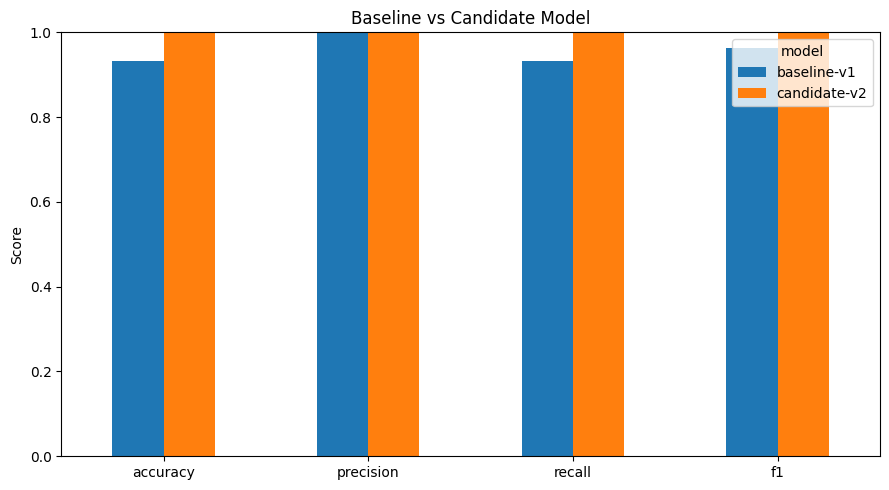

In [10]:
comparison[
    [
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
].T.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Score")
plt.title(
    "Baseline vs Candidate Model"
)

plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [11]:
metric_changes = {
    "accuracy_change":
        candidate_metrics["accuracy"]
        -
        baseline_metrics["accuracy"],

    "precision_change":
        candidate_metrics["precision"]
        -
        baseline_metrics["precision"],

    "recall_change":
        candidate_metrics["recall"]
        -
        baseline_metrics["recall"],

    "f1_change":
        candidate_metrics["f1"]
        -
        baseline_metrics["f1"],

    "failure_rate_change":
        candidate_metrics["failure_rate"]
        -
        baseline_metrics["failure_rate"]
}

pd.Series(
    metric_changes
)

,0
accuracy_change,0.066667
precision_change,0.000000
recall_change,0.066667
f1_change,0.036364
failure_rate_change,-0.066667


In [12]:
case_comparison = golden_data.copy()

case_comparison[
    "baseline_prediction"
] = baseline_results[
    "prediction"
].to_numpy()

case_comparison[
    "candidate_prediction"
] = candidate_results[
    "prediction"
].to_numpy()

case_comparison[
    "baseline_correct"
] = baseline_results[
    "correct"
].to_numpy()

case_comparison[
    "candidate_correct"
] = candidate_results[
    "correct"
].to_numpy()

case_comparison[
    "regression"
] = (
    case_comparison[
        "baseline_correct"
    ]
    &
    ~case_comparison[
        "candidate_correct"
    ]
)

case_comparison[
    "improvement"
] = (
    ~case_comparison[
        "baseline_correct"
    ]
    &
    case_comparison[
        "candidate_correct"
    ]
)

case_comparison.head()

,text,expected_label,baseline_prediction,candidate_prediction,baseline_correct,candidate_correct,regression,improvement
0,Develops backend APIs and software systems,SOFTWARE,SOFTWARE,SOFTWARE,True,True,False,False
1,Writes Python applications and maintains code,SOFTWARE,SOFTWARE,SOFTWARE,True,True,False,False
2,Builds web applications for customers,SOFTWARE,SOFTWARE,SOFTWARE,True,True,False,False
3,Designs and tests enterprise software,SOFTWARE,SOFTWARE,SOFTWARE,True,True,False,False
4,Maintains application code and fixes bugs,SOFTWARE,SOFTWARE,SOFTWARE,True,True,False,False


In [13]:
regression_cases = (
    case_comparison[
        case_comparison["regression"]
    ]
)

improvement_cases = (
    case_comparison[
        case_comparison["improvement"]
    ]
)

print(
    "New regressions:",
    len(regression_cases)
)

print(
    "Improvements:",
    len(improvement_cases)
)

regression_cases

New regressions: 0
Improvements: 2


,text,expected_label,baseline_prediction,candidate_prediction,baseline_correct,candidate_correct,regression,improvement


In [14]:
class_results = []

for label in LABELS:

    baseline_mask = (
        baseline_results[
            "expected_label"
        ]
        ==
        label
    )

    candidate_mask = (
        candidate_results[
            "expected_label"
        ]
        ==
        label
    )

    baseline_accuracy = (
        baseline_results.loc[
            baseline_mask,
            "correct"
        ].mean()
    )

    candidate_accuracy = (
        candidate_results.loc[
            candidate_mask,
            "correct"
        ].mean()
    )

    class_results.append({
        "class":
            label,

        "baseline_accuracy":
            float(
                baseline_accuracy
            ),

        "candidate_accuracy":
            float(
                candidate_accuracy
            ),

        "change":
            float(
                candidate_accuracy
                -
                baseline_accuracy
            )
    })

class_comparison = pd.DataFrame(
    class_results
)

class_comparison

,class,baseline_accuracy,candidate_accuracy,change
0,EDUCATION,1.000000,1.0,0.000000
1,FINANCE,1.000000,1.0,0.000000
2,HEALTHCARE,0.833333,1.0,0.166667
3,SOFTWARE,0.833333,1.0,0.166667
4,TRADES,1.000000,1.0,0.000000


In [15]:
worst_class_change = (
    class_comparison[
        "change"
    ].min()
)

worst_class = (
    class_comparison.loc[
        class_comparison[
            "change"
        ].idxmin(),
        "class"
    ]
)

print(
    "Worst class:",
    worst_class
)

print(
    "Worst class change:",
    f"{worst_class_change:.2%}"
)

Worst class: EDUCATION
Worst class change: 0.00%


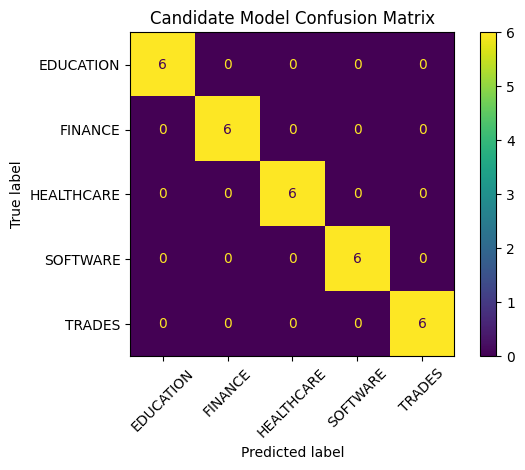

In [16]:
ConfusionMatrixDisplay.from_predictions(
    golden_data[
        "expected_label"
    ],
    candidate_results[
        "prediction"
    ],
    labels=LABELS,
    xticks_rotation=45
)

plt.title(
    "Candidate Model Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [17]:
def deployment_gate(
    baseline,
    candidate,
    class_results,
    new_regressions
):

    reasons = []

    accuracy_change = (
        candidate["accuracy"]
        -
        baseline["accuracy"]
    )

    f1_change = (
        candidate["f1"]
        -
        baseline["f1"]
    )

    worst_class_change = (
        class_results[
            "change"
        ].min()
    )

    if (
        candidate["accuracy"]
        < MIN_ACCURACY
    ):
        reasons.append(
            "ACCURACY_BELOW_MINIMUM"
        )

    if (
        accuracy_change
        < -MAX_ACCURACY_REGRESSION
    ):
        reasons.append(
            "ACCURACY_REGRESSION"
        )

    if (
        f1_change
        < -MAX_F1_REGRESSION
    ):
        reasons.append(
            "F1_REGRESSION"
        )

    if (
        candidate["failure_rate"]
        > MAX_FAILURE_RATE
    ):
        reasons.append(
            "FAILURE_RATE_TOO_HIGH"
        )

    if (
        worst_class_change
        < -MAX_CLASS_REGRESSION
    ):
        reasons.append(
            "CLASS_REGRESSION"
        )

    if (
        new_regressions
        > MAX_NEW_REGRESSIONS
    ):
        reasons.append(
            "TOO_MANY_CASE_REGRESSIONS"
        )

    return {
        "decision":
            "PASS"
            if not reasons
            else "FAIL",

        "reasons":
            reasons,

        "accuracy_change":
            float(
                accuracy_change
            ),

        "f1_change":
            float(
                f1_change
            ),

        "worst_class_change":
            float(
                worst_class_change
            ),

        "new_regressions":
            int(
                new_regressions
            )
    }

In [18]:
new_regressions = int(
    case_comparison[
        "regression"
    ].sum()
)

gate_result = deployment_gate(
    baseline=
        baseline_metrics,

    candidate=
        candidate_metrics,

    class_results=
        class_comparison,

    new_regressions=
        new_regressions
)

gate_result

{'decision': 'PASS',
 'reasons': [],
 'accuracy_change': 0.06666666666666665,
 'f1_change': 0.036363636363636376,
 'worst_class_change': 0.0,
 'new_regressions': 0}

In [19]:
evaluation_report = {
    "timestamp":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "evaluation_set": {
        "examples":
            len(golden_data),

        "classes":
            LABELS
    },

    "baseline":
        baseline_metrics,

    "candidate":
        candidate_metrics,

    "metric_changes":
        {
            key: float(value)
            for key, value
            in metric_changes.items()
        },

    "deployment_gate":
        gate_result,

    "regression_cases":
        regression_cases[
            [
                "text",
                "expected_label",
                "baseline_prediction",
                "candidate_prediction"
            ]
        ].to_dict(
            orient="records"
        ),

    "class_results":
        class_comparison.to_dict(
            orient="records"
        )
}

In [20]:
REPORT_PATH = (
    ARTIFACT_DIR
    / "evaluation_report.json"
)

CASE_RESULTS_PATH = (
    ARTIFACT_DIR
    / "case_results.csv"
)

CLASS_RESULTS_PATH = (
    ARTIFACT_DIR
    / "class_results.csv"
)


with open(
    REPORT_PATH,
    "w"
) as file:

    json.dump(
        evaluation_report,
        file,
        indent=4
    )


case_comparison.to_csv(
    CASE_RESULTS_PATH,
    index=False
)


class_comparison.to_csv(
    CLASS_RESULTS_PATH,
    index=False
)


print(
    "Saved:",
    REPORT_PATH
)

print(
    "Saved:",
    CASE_RESULTS_PATH
)

print(
    "Saved:",
    CLASS_RESULTS_PATH
)

Saved: llm_eval_artifacts/evaluation_report.json
Saved: llm_eval_artifacts/case_results.csv
Saved: llm_eval_artifacts/class_results.csv


In [21]:
def promotion_check(
    fail_on_error=False
):

    passed = (
        gate_result[
            "decision"
        ]
        ==
        "PASS"
    )

    if (
        not passed
        and fail_on_error
    ):

        raise RuntimeError(
            "Deployment blocked: "
            +
            ", ".join(
                gate_result[
                    "reasons"
                ]
            )
        )

    return passed

In [22]:
def smoke_test():

    # Golden dataset
    assert len(
        golden_data
    ) == 30

    assert (
        golden_data[
            "expected_label"
        ].nunique()
        ==
        5
    )

    # Evaluation
    for metrics in [
        baseline_metrics,
        candidate_metrics
    ]:

        for metric in [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "failure_rate"
        ]:

            assert (
                0
                <= metrics[metric]
                <= 1
            )

    # Case analysis
    assert (
        len(case_comparison)
        ==
        len(golden_data)
    )

    assert (
        case_comparison[
            "regression"
        ].dtype
        ==
        bool
    )

    # Class analysis
    assert (
        len(class_comparison)
        ==
        len(LABELS)
    )

    assert (
        class_comparison[
            "change"
        ].between(
            -1,
            1
        ).all()
    )

    # Deployment gate
    assert (
        gate_result[
            "decision"
        ]
        in {
            "PASS",
            "FAIL"
        }
    )

    # Artifacts
    assert REPORT_PATH.exists()
    assert CASE_RESULTS_PATH.exists()
    assert CLASS_RESULTS_PATH.exists()

    print(
        "✅ LLM evaluation and regression framework passed."
    )


smoke_test()

✅ LLM evaluation and regression framework passed.
